# 04 — Modelagem preditiva

Compara baseline, Random Forest e boosting; faz tuning apenas no treino, avalia cinco métricas no teste, seleciona por F1 de CV e salva o melhor Pipeline em joblib.

In [1]:
from pathlib import Path
import sys

# O notebook pode ser executado a partir da raiz ou da pasta notebooks/.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: /Users/djalma.rodrigues/projetos/99_Revisar/projeto-ia-ciencia-dados-2026


## Modelos e protocolo

- Baseline: Regressão Logística balanceada.
- Candidatos: Random Forest e HistGradientBoosting.
- Validação: 5 folds estratificados no treino.
- Tuning: `RandomizedSearchCV`, quatro configurações por modelo avançado.
- Seleção: maior F1 médio de CV; teste não participa.

XGBoost foi testado quanto à importabilidade, mas requer `libomp.dylib` global neste macOS. A instalação de sistema é proibida pelo escopo; por isso usa-se o boosting nativo do scikit-learn.

In [2]:
from src.training import train_and_evaluate

metrics, model_metadata = train_and_evaluate()
display(metrics.style.format({
    "cv_f1_mean": "{:.4f}", "cv_f1_std": "{:.4f}", "accuracy": "{:.4f}",
    "precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}", "roc_auc": "{:.4f}",
    "tempo_segundos": "{:.1f}",
}))
print("Melhor modelo:", model_metadata["melhor_modelo"])
print("Critério:", model_metadata["criterio_selecao"])
print("Teste usado na seleção?", model_metadata["teste_usado_na_selecao"])

,modelo,cv_f1_mean,cv_f1_std,best_params,tempo_segundos,accuracy,precision,recall,f1,roc_auc
0,Regressão Logística,0.8607,0.0128,parâmetros padrão documentados,0.4,0.8738,0.8626,0.8944,0.8782,0.9454
1,HistGradientBoosting,0.8541,0.0119,"{""model__l2_regularization"": 0.0, ""model__learning_rate"": 0.1, ""model__max_iter"": 250, ""model__max_leaf_nodes"": 31}",82.4,0.8583,0.8584,0.8639,0.8611,0.9361
2,Random Forest,0.8349,0.0085,"{""model__max_depth"": 18, ""model__max_features"": 0.5, ""model__min_samples_leaf"": 2, ""model__n_estimators"": 350}",195.5,0.8311,0.8237,0.8499,0.8366,0.9201


Melhor modelo: Regressão Logística
Critério: maior F1 médio em validação cruzada estratificada de 5 folds no treino
Teste usado na seleção? False


## Visualizações do desempenho e interpretação

modelo_01_comparacao_metricas.png


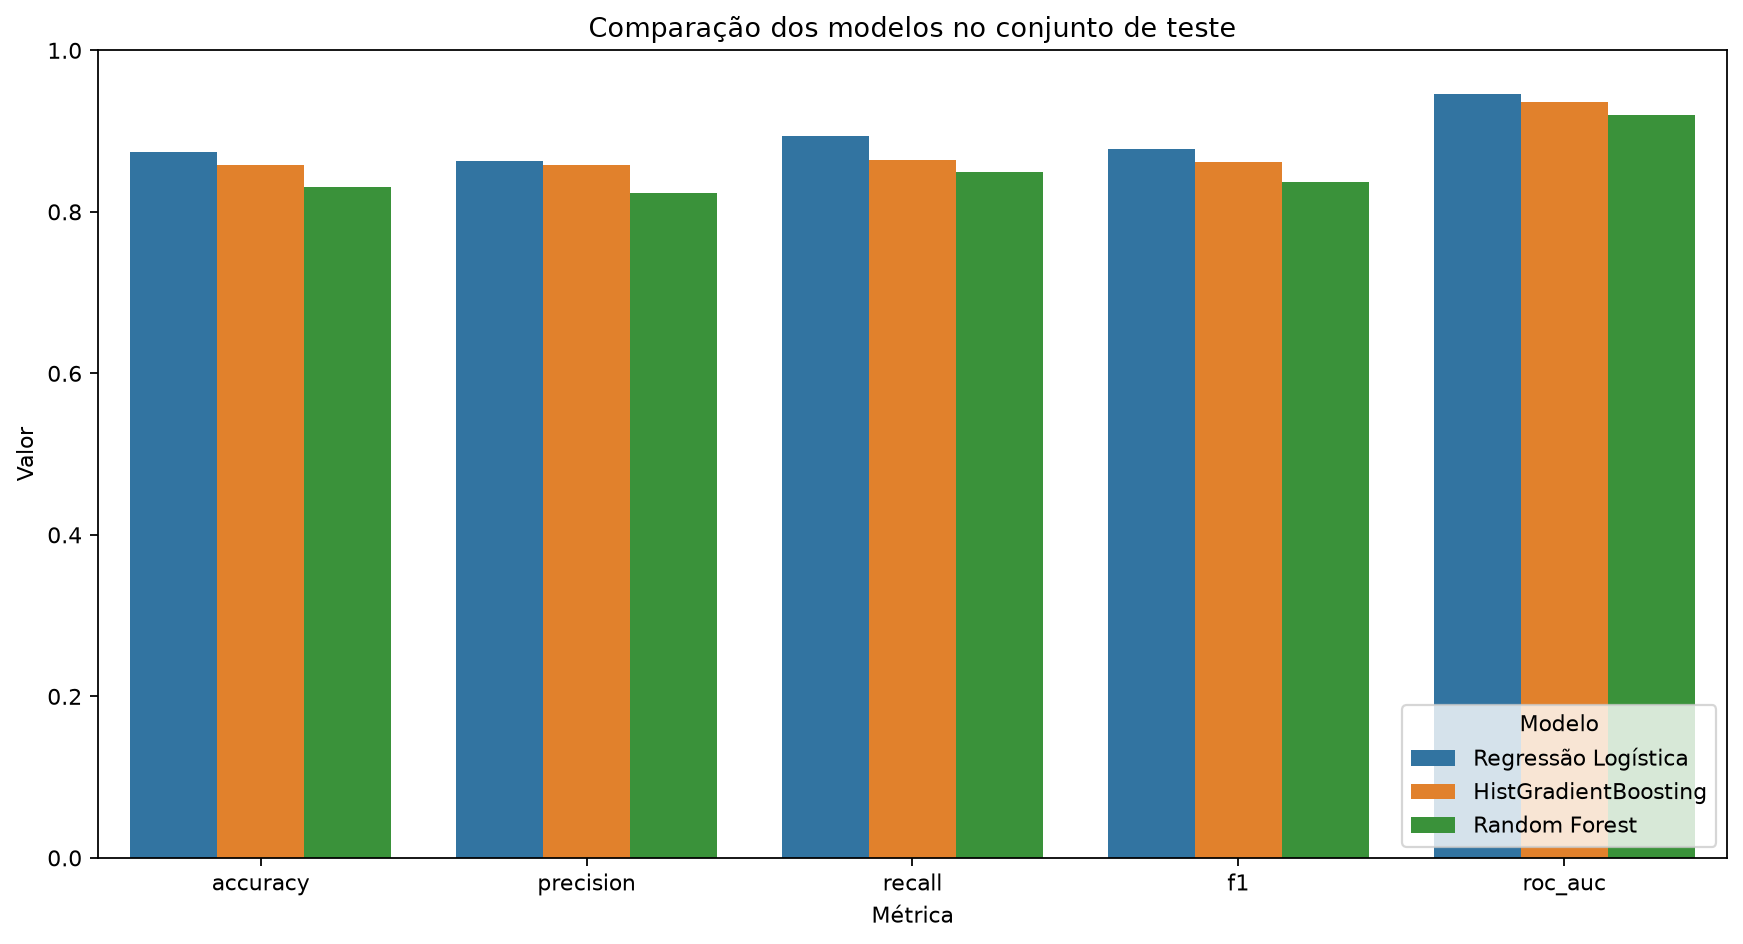

modelo_02_curvas_roc.png


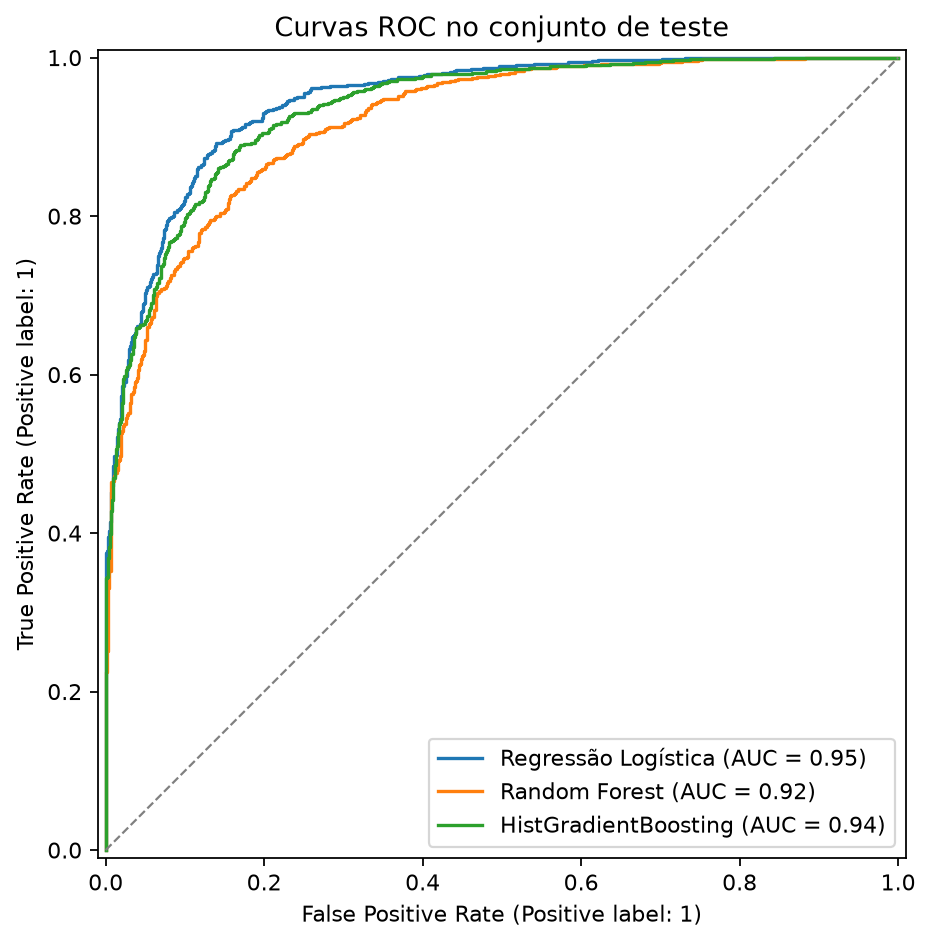

modelo_03_matriz_confusao.png


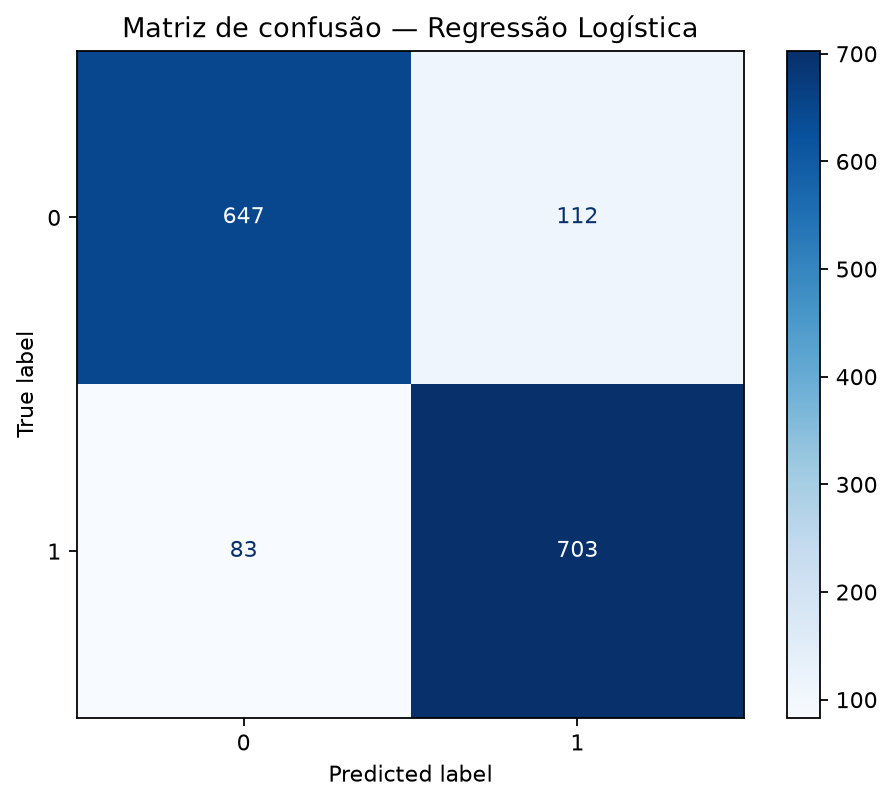

modelo_04_importancia_features.png


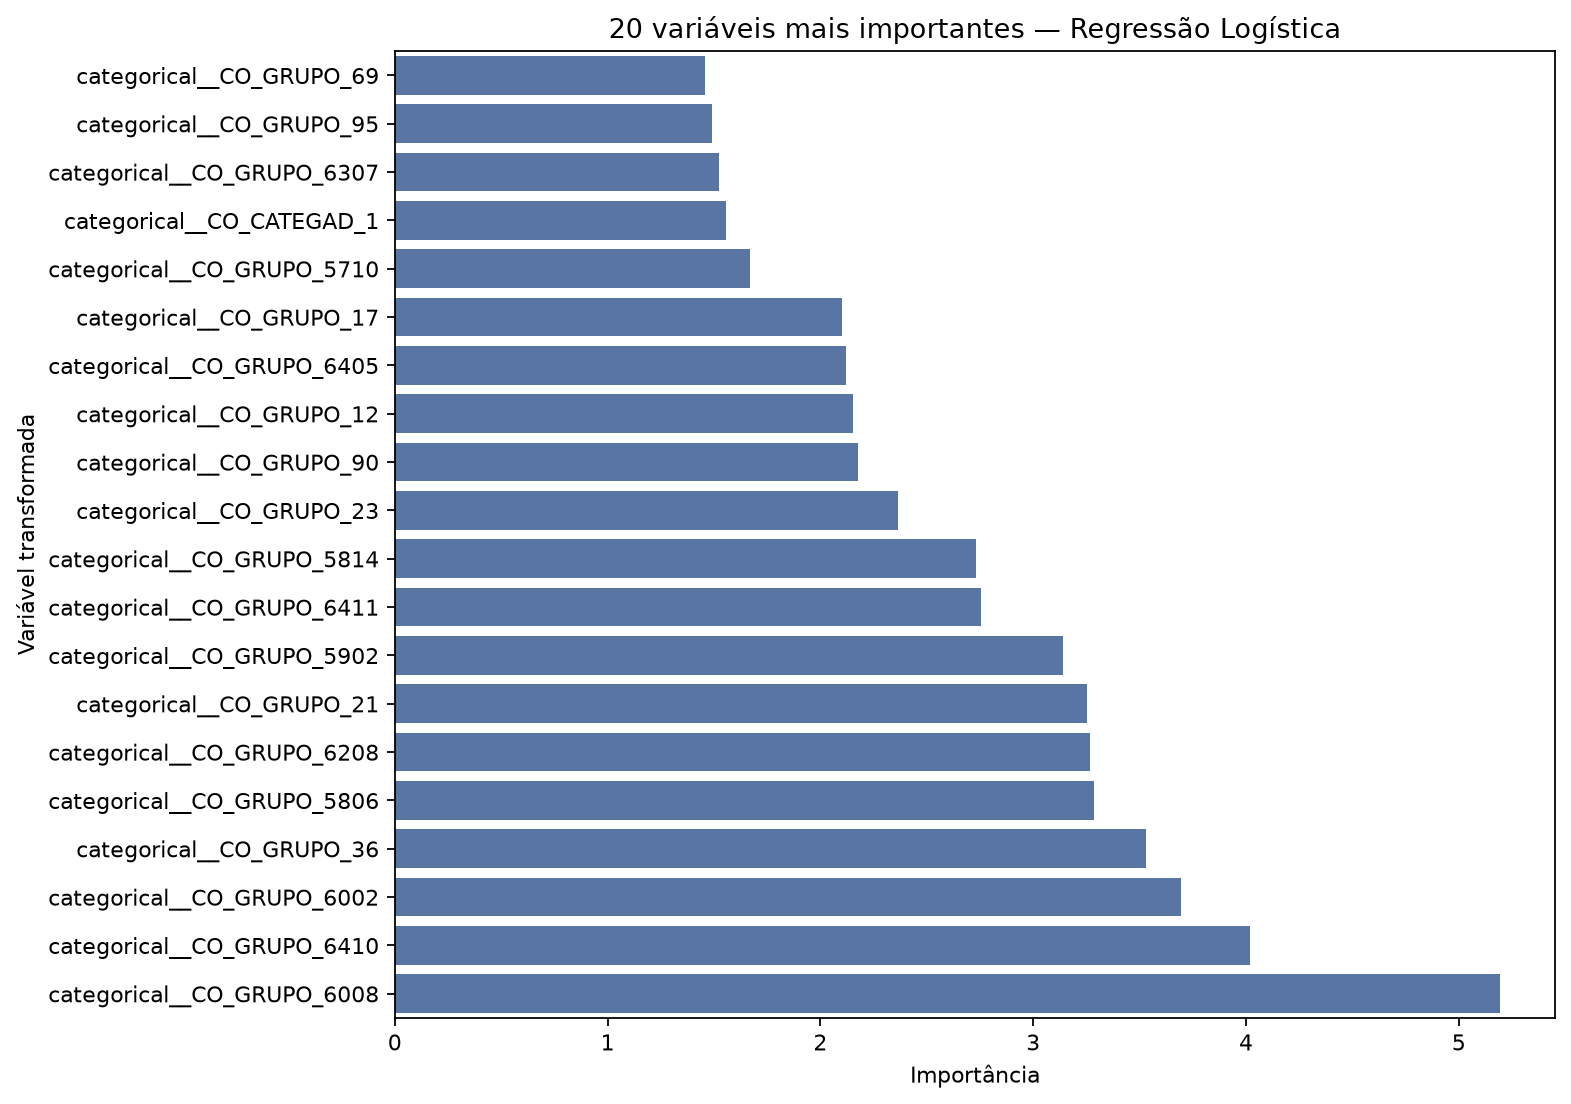

Modelo salvo: /Users/djalma.rodrigues/projetos/99_Revisar/projeto-ia-ciencia-dados-2026/models/melhor_modelo.joblib


,feature,importance
0,categorical__CO_GRUPO_6008,5.194206
1,categorical__CO_GRUPO_6410,4.016696
2,categorical__CO_GRUPO_6002,3.695656
3,categorical__CO_GRUPO_36,3.531445
4,categorical__CO_GRUPO_5806,3.286228
5,categorical__CO_GRUPO_6208,3.268384
6,categorical__CO_GRUPO_21,3.254687
7,categorical__CO_GRUPO_5902,3.140896
8,categorical__CO_GRUPO_6411,2.752884
9,categorical__CO_GRUPO_5814,2.732808


In [3]:
from IPython.display import Image, display
from src.config import FIGURES_DIR, MODELS_DIR, TABLES_DIR

for name in [
    "modelo_01_comparacao_metricas.png",
    "modelo_02_curvas_roc.png",
    "modelo_03_matriz_confusao.png",
    "modelo_04_importancia_features.png",
]:
    print(name)
    display(Image(filename=str(FIGURES_DIR / name), width=850))

print("Modelo salvo:", MODELS_DIR / "melhor_modelo.joblib")
display(__import__("pandas").read_csv(TABLES_DIR / "importancia_features.csv").head(20))

## Leitura técnica

O resultado deve ser comparado ao baseline e lido em conjunto com Precision, Recall e ROC-AUC. Acurácia isolada não governa a seleção. Importâncias/coeficientes descrevem contribuição preditiva condicional, não causalidade. O `joblib` contém o Pipeline completo, inclusive imputação, clipping, escala e encoding.